# Exercise 2: Multi-Agent Systems with LangGraph

In this exercise, you will learn to:
1. Build a supervisor pattern with multiple specialized agents
2. Implement agent-to-agent communication
3. Create a collaborative multi-agent workflow
4. Handle shared state across agents

**Prerequisites**: Complete Exercise 1 (Advanced Agents) first.

## Setup

In [1]:
# Install required packages
!pip3 install langchain langchain-openai langgraph --quiet


[notice] A new release of pip available: 22.3.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import os
from dotenv import load_dotenv

load_dotenv()

# Verify that the required environment variables are set
assert os.environ.get("OPENAI_API_KEY"), "OPENAI_API_KEY is not set! Check your .env file."
assert os.environ.get("OPENAI_ENDPOINT"), "OPENAI_ENDPOINT is not set! Check your .env file."

from langchain_openai import ChatOpenAI

print("Environment variables loaded successfully!")

Environment variables loaded successfully!


In [3]:
from typing import Annotated, TypedDict, Literal, Sequence
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage, BaseMessage
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import create_react_agent, ToolNode
import json
import operator

# Initialize the LLM
llm = ChatOpenAI(base_url=os.environ["OPENAI_ENDPOINT"], model="model-group3")
#llm = ChatOpenAI(base_url=os.environ["OPENAI_ENDPOINT"], model="gpt-5.4-mini")

## Part 1: Understanding Multi-Agent Architectures

Multi-agent systems allow you to:
- **Specialize**: Each agent focuses on one domain
- **Scale**: Handle complex tasks by dividing work
- **Collaborate**: Agents can build on each other's work

In [7]:
# Let's visualize the supervisor pattern we'll build
print("""
┌─────────────────────────────────────────────────────────────┐
│                    SUPERVISOR PATTERN                       │
├─────────────────────────────────────────────────────────────┤
│                                                             │
│                     ┌──────────────┐                        │
│      User ─────────▶│  SUPERVISOR  │                        │
│                     │   (Router)   │                        │
│                     └──────┬───────┘                        │
│                            │                                │
│         ┌──────────────────┼──────────────────┐             │
│         ▼                  ▼                  ▼             │
│   ┌───────────┐     ┌───────────┐     ┌───────────┐        │
│   │ RESEARCHER│     │   CODER   │     │  WRITER   │        │
│   │   Agent   │     │   Agent   │     │   Agent   │        │
│   └───────────┘     └───────────┘     └───────────┘        │
│                                                             │
└─────────────────────────────────────────────────────────────┘

The supervisor decides which agent should handle each task,
then aggregates results and continues until the task is complete.
""")


┌─────────────────────────────────────────────────────────────┐
│                    SUPERVISOR PATTERN                       │
├─────────────────────────────────────────────────────────────┤
│                                                             │
│                     ┌──────────────┐                        │
│      User ─────────▶│  SUPERVISOR  │                        │
│                     │   (Router)   │                        │
│                     └──────┬───────┘                        │
│                            │                                │
│         ┌──────────────────┼──────────────────┐             │
│         ▼                  ▼                  ▼             │
│   ┌───────────┐     ┌───────────┐     ┌───────────┐        │
│   │ RESEARCHER│     │   CODER   │     │  WRITER   │        │
│   │   Agent   │     │   Agent   │     │   Agent   │        │
│   └───────────┘     └───────────┘     └───────────┘        │
│                                          

## Part 2: Building the Supervisor Pattern

We'll create a research team with:
- **Supervisor**: Routes tasks to the right agent
- **Researcher**: Finds information
- **Coder**: Writes and analyzes code
- **Writer**: Creates written content

In [4]:
# Define tools for each specialized agent

# Researcher tools
@tool
def web_search(query: str) -> str:
    """Search the web for information on a topic."""
    # Simulated search results
    results = {
        "python": "Python is a high-level programming language known for readability. Latest version: 3.12. Popular for AI/ML.",
        "langchain": "LangChain is a framework for building LLM applications. Key features: chains, agents, memory, tools.",
        "react": "React is a JavaScript library for building user interfaces. Developed by Facebook. Uses virtual DOM.",
        "default": f"Search results for '{query}': Found information about the topic including key facts and recent developments."
    }
    for key in results:
        if key in query.lower():
            return results[key]
    return results["default"]

@tool
def get_facts(topic: str) -> str:
    """Get factual information about a topic."""
    return f"Key facts about {topic}: This is a significant topic with multiple aspects worth exploring."

# Coder tools
@tool
def write_code(language: str, task: str) -> str:
    """Write code in a specified language for a given task."""
    code_examples = {
        "python": f'''```python
# Solution for: {task}
def solution():
    # Implementation here
    result = "Task completed"
    return result

if __name__ == "__main__":
    print(solution())
```''',
        "javascript": f'''```javascript
// Solution for: {task}
function solution() {{
    const result = "Task completed";
    return result;
}}
console.log(solution());
```'''
    }
    return code_examples.get(language.lower(), f"```{language}\n// Code for {task}\n```")

@tool
def analyze_code(code: str) -> str:
    """Analyze code for potential issues and improvements."""
    return f"Code analysis: The code appears well-structured. Suggestions: Add error handling, consider edge cases, add documentation."

# Writer tools
@tool
def write_document(title: str, content_type: str, key_points: str) -> str:
    """Write a document with specified title, type (blog, report, summary), and key points."""
    return f"""# {title}

## Overview
This {content_type} covers the following key points:

{key_points}

## Conclusion
In summary, these points highlight the importance of understanding {title.lower()}.
"""

@tool
def summarize(text: str) -> str:
    """Summarize a piece of text."""
    words = text.split()
    summary_length = min(30, len(words) // 2)
    return f"Summary: {' '.join(words[:summary_length])}..."

print("Tools defined for all agents!")

Tools defined for all agents!


In [5]:
# Define the multi-agent state
class MultiAgentState(TypedDict):
    messages: Annotated[list, add_messages]
    next_agent: str
    task_completed: bool
    research_findings: str
    code_output: str
    written_content: str
    fact_check_results: str

# Agent names
AGENTS = ["researcher", "coder", "writer", "fact_checker"]

# Supervisor system prompt
SUPERVISOR_PROMPT = """You are a supervisor managing a team of agents: {agents}.

Your job is to:
1. Analyze the user's request
2. Decide which agent should handle it (or if it's complete)
3. Route to the appropriate agent

Agent capabilities:
- researcher: Searches for information, gathers facts
- coder: Writes and analyzes code
- writer: Creates documents, summaries, blog posts
- fact_checker: Verifies claims and facts for accuracy

Respond with ONLY the agent name or 'FINISH' if the task is complete.
Agent names: researcher, coder, writer, fact_checker, FINISH

Current task progress:
- Research findings: {research}
- Code output: {code}
- Written content: {writing}
- Fact check results: {fact_check}
"""

In [13]:
# Create the supervisor node
def supervisor_node(state: MultiAgentState) -> dict:
    """The supervisor decides which agent should act next."""
    messages = state["messages"]
    
    # Format the supervisor prompt with current state
    prompt = SUPERVISOR_PROMPT.format(
        agents=", ".join(AGENTS),
        research=state.get("research_findings", "None yet"),
        code=state.get("code_output", "None yet"),
        writing=state.get("written_content", "None yet"),
        fact_check=state.get("fact_check_results", "None yet")
    )
    
    response = llm.invoke([
        SystemMessage(content=prompt),
        *messages
    ])
    
    # Parse the response to get the next agent
    next_agent = response.content.strip().lower()
    
    # Validate the response
    if next_agent not in AGENTS and next_agent != "finish":
        # Default to finish if invalid response
        next_agent = "finish"
    
    print(f"\n🎯 Supervisor decision: Route to '{next_agent}'")
    
    return {
        "next_agent": next_agent,
        "task_completed": next_agent == "finish"
    }

def route_to_agent(state: MultiAgentState) -> str:
    """Route based on supervisor's decision."""
    next_agent = state["next_agent"]
    if next_agent == "finish":
        return "finish"
    return next_agent

In [14]:
# Create agent nodes
researcher_tools = [web_search, get_facts]
coder_tools = [write_code, analyze_code]
writer_tools = [write_document, summarize]

# Fact checker tools
@tool
def verify_claim(claim: str) -> str:
    """Verify if a claim is accurate."""
    # Simple fact-checking simulation
    claim_lower = claim.lower()
    
    # Known facts for verification
    facts = {
        "python": "Python is a high-level programming language known for readability. Latest version: 3.12.",
        "langchain": "LangChain is a framework for building LLM applications with chains, agents, memory, and tools.",
        "react": "React is a JavaScript library for building user interfaces developed by Facebook.",
        "fibonacci": "Fibonacci sequence is a series where each number is the sum of the two preceding ones.",
    }
    
    for key, fact in facts.items():
        if key in claim_lower:
            return f"✅ VERIFIED: {fact}"
        
        
    # If no match, return unverified
    return f"❌ UNVERIFIED: Claim '{claim}' could not be verified with available knowledge. Further research needed."

fact_checker_tools = [verify_claim]

def create_agent_node(name: str, tools: list, system_prompt: str):
    """Factory function to create agent nodes."""
    agent_llm = llm.bind_tools(tools)
    tool_node = ToolNode(tools)
    
    def agent_node(state: MultiAgentState) -> dict:
        """Execute the agent's task."""
        messages = state["messages"]
        
        print(f"\n🤖 {name.upper()} Agent working...")
        
        # Create agent-specific context
        agent_messages = [
            SystemMessage(content=system_prompt),
            *messages
        ]
        
        # Get agent's response
        response = agent_llm.invoke(agent_messages)
        
        # Execute any tool calls
        result_content = response.content
        if hasattr(response, 'tool_calls') and response.tool_calls:
            for tc in response.tool_calls:
                tool_name = tc['name']
                tool_args = tc['args']
                # Find and execute the tool
                for t in tools:
                    if t.name == tool_name:
                        tool_result = t.invoke(tool_args)
                        result_content = f"{response.content}\n\nTool '{tool_name}' result:\n{tool_result}"
                        print(f"   🔧 Used tool: {tool_name}")
        
        # Create the agent's message
        agent_message = AIMessage(content=f"[{name.upper()}]: {result_content}")
        
        # Update the appropriate state field
        updates = {"messages": [agent_message]}
        if name == "researcher":
            updates["research_findings"] = result_content
        elif name == "coder":
            updates["code_output"] = result_content
        elif name == "writer":
            updates["written_content"] = result_content
        elif name == "fact_checker":
            updates["fact_check_results"] = result_content  # Add a new field for fact checking
        
        return updates
    
    return agent_node

# Create the agent nodes
researcher_node = create_agent_node(
    "researcher",
    researcher_tools,
    "You are a research agent. Find information and facts relevant to the user's request. Be thorough and cite your sources."
)

coder_node = create_agent_node(
    "coder",
    coder_tools,
    "You are a coding agent. Write clean, well-documented code. If given existing code, analyze it and suggest improvements."
)

writer_node = create_agent_node(
    "writer",
    writer_tools,
    "You are a writing agent. Create clear, engaging content. Use the research and code outputs if available."
)

fact_checker_node = create_agent_node(
    "fact_checker",
    fact_checker_tools,
    "You are a fact-checking agent. Verify claims made by other agents for accuracy. Use the verify_claim tool to check facts."
)

def finish_node(state: MultiAgentState) -> dict:
    """Final node that compiles the results."""
    print("\n✅ Task completed!")
    
    summary = ["\n=== FINAL OUTPUT ==="]
    if state.get("research_findings"):
        summary.append(f"\n📚 Research:\n{state['research_findings'][:200]}...")
    if state.get("code_output"):
        summary.append(f"\n💻 Code:\n{state['code_output'][:200]}...")
    if state.get("written_content"):
        summary.append(f"\n📝 Writing:\n{state['written_content'][:200]}...")
    if state.get("fact_check_results"):
        summary.append(f"\n🔍 Fact Check:\n{state['fact_check_results'][:200]}...")
    
    final_message = AIMessage(content="\n".join(summary))
    return {"messages": [final_message]}

print("Agent nodes created!")

Agent nodes created!


In [15]:
# Build the multi-agent graph
multi_agent_graph = StateGraph(MultiAgentState)

# Add all nodes
multi_agent_graph.add_node("supervisor", supervisor_node)
multi_agent_graph.add_node("researcher", researcher_node)
multi_agent_graph.add_node("coder", coder_node)
multi_agent_graph.add_node("writer", writer_node)
multi_agent_graph.add_node("fact_checker", fact_checker_node)
multi_agent_graph.add_node("finish", finish_node)

# Add edges
multi_agent_graph.add_edge(START, "supervisor")

multi_agent_graph.add_conditional_edges(
    "supervisor",
    route_to_agent,
    {
        "researcher": "researcher",
        "coder": "coder",
        "writer": "writer",
        "fact_checker": "fact_checker",
        "finish": "finish"
    }
)

# After each agent, go back to supervisor
for agent in AGENTS:
    multi_agent_graph.add_edge(agent, "supervisor")

# Finish goes to END
multi_agent_graph.add_edge("finish", END)

# Compile
multi_agent_app = multi_agent_graph.compile()

print("Multi-agent graph compiled!")

Multi-agent graph compiled!


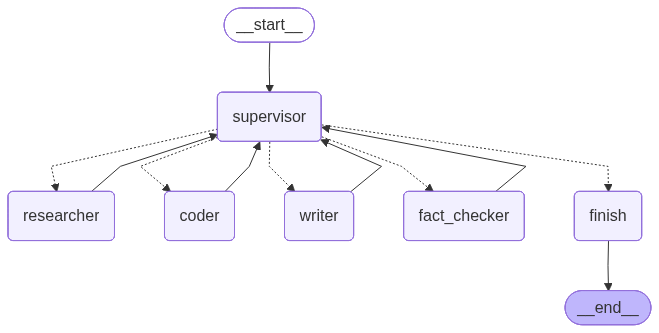

In [16]:
# Visualize the graph
try:
    from IPython.display import Image, display
    display(Image(multi_agent_app.get_graph().draw_mermaid_png()))
except:
    print(multi_agent_app.get_graph().draw_ascii())

In [17]:
# Test the multi-agent system!
def run_multi_agent(query: str):
    """Run the multi-agent system with a query."""
    print(f"\n{'='*60}")
    print(f"📋 TASK: {query}")
    print('='*60)
    
    initial_state = {
        "messages": [HumanMessage(content=query)],
        "next_agent": "",
        "task_completed": False,
        "research_findings": "",
        "code_output": "",
        "written_content": "",
        "fact_check_results": ""
    }
    
    result = multi_agent_app.invoke(initial_state)
    
    print("\n" + "="*60)
    print("📊 FINAL RESULT")
    print("="*60)
    print(result["messages"][-1].content)
    
    return result

In [18]:
# Test with a coding task
run_multi_agent("Write a Python function to calculate fibonacci numbers and explain how it works.")


📋 TASK: Write a Python function to calculate fibonacci numbers and explain how it works.

🎯 Supervisor decision: Route to 'writer'

🤖 WRITER Agent working...

🎯 Supervisor decision: Route to 'finish'

✅ Task completed!

📊 FINAL RESULT

=== FINAL OUTPUT ===

📝 Writing:
```python
def fibonacci(n):
    """Return the nth Fibonacci number (0-indexed)."""
    if n < 0:
        raise ValueError("n must be non-negative")
    if n == 0:
        return 0
    if n == 1:
     ...


{'messages': [HumanMessage(content='Write a Python function to calculate fibonacci numbers and explain how it works.', additional_kwargs={}, response_metadata={}, id='b83701ef-ef28-42fe-811f-d0a8403ef4dd'),
  AIMessage(content='[WRITER]: ```python\ndef fibonacci(n):\n    """Return the nth Fibonacci number (0-indexed)."""\n    if n < 0:\n        raise ValueError("n must be non-negative")\n    if n == 0:\n        return 0\n    if n == 1:\n        return 1\n\n    a, b = 0, 1\n    for _ in range(2, n + 1):\n        a, b = b, a + b\n    return b\n```\n\n### How it works\nThe Fibonacci sequence starts like this:\n\n`0, 1, 1, 2, 3, 5, 8, 13, ...`\n\nEach number is the sum of the two before it.\n\n- `fibonacci(0) -> 0`\n- `fibonacci(1) -> 1`\n- `fibonacci(2) -> 1`\n- `fibonacci(3) -> 2`\n- and so on\n\n### Explanation of the code\n- The function first checks that `n` is not negative.\n- It handles the first two values directly:\n  - `0` returns `0`\n  - `1` returns `1`\n- For larger values, it

In [12]:
# Test with a complex multi-step task
run_multi_agent(
    "Research LangChain, then write Python code that demonstrates its key features, "
    "and finally write a blog post explaining the code."
)


📋 TASK: Research LangChain, then write Python code that demonstrates its key features, and finally write a blog post explaining the code.

🎯 Supervisor decision: Route to 'researcher'

🤖 RESEARCHER Agent working...
   🔧 Used tool: web_search
   🔧 Used tool: get_facts
   🔧 Used tool: web_search
   🔧 Used tool: web_search

🎯 Supervisor decision: Route to 'coder'

🤖 CODER Agent working...
   🔧 Used tool: write_code
   🔧 Used tool: write_code

🎯 Supervisor decision: Route to 'writer'

🤖 WRITER Agent working...
   🔧 Used tool: write_document
   🔧 Used tool: write_document

🎯 Supervisor decision: Route to 'finish'

✅ Task completed!

📊 FINAL RESULT

=== FINAL OUTPUT ===

📚 Research:


Tool 'web_search' result:
LangChain is a framework for building LLM applications. Key features: chains, agents, memory, tools....

💻 Code:


Tool 'write_code' result:
```markdown
// Code for Write a blog post that explains a Python script demonstrating LangChain's key features. The blog post should:
- Start wi

{'messages': [HumanMessage(content='Research LangChain, then write Python code that demonstrates its key features, and finally write a blog post explaining the code.', additional_kwargs={}, response_metadata={}, id='9f0ac47d-820e-4408-bf5c-8d365f4aeee3'),
  AIMessage(content="[RESEARCHER]: \n\nTool 'web_search' result:\nLangChain is a framework for building LLM applications. Key features: chains, agents, memory, tools.", additional_kwargs={}, response_metadata={}, id='1cf5ac9c-db51-4b95-a407-050ad22d5e6a', tool_calls=[], invalid_tool_calls=[]),
  AIMessage(content="[CODER]: \n\nTool 'write_code' result:\n```markdown\n// Code for Write a blog post that explains a Python script demonstrating LangChain's key features. The blog post should:\n- Start with a concise introduction to what LangChain is\n- Explain the code section by section\n- Cover prompt templates, model invocation, retrieval augmented generation, tools/agents, and memory/state\n- Be friendly, educational, and moderately deta

## Part 3: Collaborative Pattern (Agent Debate)

Let's implement a collaborative pattern where agents iterate on a shared artifact.

In [19]:
# State for collaborative agents
class CollaborativeState(TypedDict):
    messages: Annotated[list, add_messages]
    draft: str
    critiques: list[str]
    iteration: int
    max_iterations: int
    is_approved: bool

# Writer agent creates/revises content
def collaborative_writer(state: CollaborativeState) -> dict:
    """Write or revise the draft based on critiques."""
    iteration = state.get("iteration", 0) + 1
    current_draft = state.get("draft", "")
    critiques = state.get("critiques", [])
    
    print(f"\n✍️  Writer (Iteration {iteration})")
    
    if not current_draft:
        # First draft
        prompt = f"""Write a first draft based on this request:
        {state['messages'][0].content}

        Create a clear, well-structured piece of writing."""
    else:
        # Revision
        prompt = f"""Revise this draft based on the critiques:

                CURRENT DRAFT:
                {current_draft}

                CRITIQUES:
                {chr(10).join(critiques)}

                Create an improved version addressing the feedback."""
    
    response = llm.invoke([HumanMessage(content=prompt)])
    new_draft = response.content
    
    print(f"   Draft updated ({len(new_draft)} chars)")
    
    return {
        "draft": new_draft,
        "iteration": iteration,
        "messages": [AIMessage(content=f"[WRITER] Draft v{iteration} created.")]
    }

# Critic agent reviews and critiques
def collaborative_critic(state: CollaborativeState) -> dict:
    """Critique the current draft."""
    draft = state["draft"]
    iteration = state["iteration"]
    
    print(f"\n🔍 Critic reviewing...")
    
    prompt = f"""Review this draft and provide constructive criticism:

                DRAFT:
                {draft}

                Provide specific, actionable feedback. If the draft is excellent and needs no changes, 
                respond with exactly: APPROVED

                Otherwise, list 2-3 specific improvements needed."""
    
    response = llm.invoke([HumanMessage(content=prompt)])
    critique = response.content
    
    is_approved = "APPROVED" in critique.upper()
    
    if is_approved:
        print("   ✅ Approved!")
    else:
        print(f"   📝 Feedback provided")
    
    return {
        "critiques": [critique],
        "is_approved": is_approved,
        "messages": [AIMessage(content=f"[CRITIC] Review complete. Approved: {is_approved}")]
    }

def should_continue_collaboration(state: CollaborativeState) -> str:
    """Check if we should continue iterating."""
    if state.get("is_approved"):
        return "end"
    if state.get("iteration", 0) >= state.get("max_iterations", 3):
        return "end"
    return "writer"

In [20]:
# Build the collaborative graph
collab_graph = StateGraph(CollaborativeState)

collab_graph.add_node("writer", collaborative_writer)
collab_graph.add_node("critic", collaborative_critic)

collab_graph.add_edge(START, "writer")
collab_graph.add_edge("writer", "critic")
collab_graph.add_conditional_edges(
    "critic",
    should_continue_collaboration,
    {"writer": "writer", "end": END}
)

collab_app = collab_graph.compile()
print("Collaborative graph compiled!")

Collaborative graph compiled!


In [10]:
# Test the collaborative system
def run_collaborative(task: str, max_iterations: int = 3):
    """Run the collaborative writer-critic system."""
    print(f"\n{'='*60}")
    print(f"📋 COLLABORATIVE TASK: {task}")
    print(f"   Max iterations: {max_iterations}")
    print('='*60)
    
    initial_state = {
        "messages": [HumanMessage(content=task)],
        "draft": "",
        "critiques": [],
        "iteration": 0,
        "max_iterations": max_iterations,
        "is_approved": False
    }
    
    result = collab_app.invoke(initial_state)
    
    print("\n" + "="*60)
    print("📊 FINAL DRAFT")
    print("="*60)
    print(f"Iterations: {result['iteration']}")
    print(f"Approved: {result['is_approved']}")
    print("\n" + result["draft"])
    
    return result

# Test with a writing task
run_collaborative("Write a short paragraph explaining why Python is popular for data science.")


📋 COLLABORATIVE TASK: Write a short paragraph explaining why Python is popular for data science.
   Max iterations: 3

✍️  Writer (Iteration 1)
   Draft updated (590 chars)

🔍 Critic reviewing...
   📝 Feedback provided

✍️  Writer (Iteration 2)
   Draft updated (631 chars)

🔍 Critic reviewing...
   📝 Feedback provided

✍️  Writer (Iteration 3)
   Draft updated (927 chars)

🔍 Critic reviewing...
   📝 Feedback provided

📊 FINAL DRAFT
Iterations: 3
Approved: False

Python is one of the most widely used languages in data science, and its popularity is backed by a large ecosystem of tools and community support. According to the 2024 Stack Overflow Developer Survey, Python remains among the most commonly used programming languages, reflecting its strong role in analytics and machine learning. A data analyst can use pandas to clean a messy dataset, Matplotlib to visualize trends, and scikit-learn to build a model—all within the same language. This makes Python especially valuable for iterati

{'messages': [HumanMessage(content='Write a short paragraph explaining why Python is popular for data science.', additional_kwargs={}, response_metadata={}, id='c62a87bd-0499-4b2d-b913-57b783bbf4d9'),
  AIMessage(content='[WRITER] Draft v1 created.', additional_kwargs={}, response_metadata={}, id='29db67d3-9f29-489f-805c-ec7001a8374e', tool_calls=[], invalid_tool_calls=[]),
  AIMessage(content='[CRITIC] Review complete. Approved: False', additional_kwargs={}, response_metadata={}, id='33113932-1aff-4efa-a3f9-e654f837ab2e', tool_calls=[], invalid_tool_calls=[]),
  AIMessage(content='[WRITER] Draft v2 created.', additional_kwargs={}, response_metadata={}, id='b9936752-8b11-4015-a48b-0d6966305dcb', tool_calls=[], invalid_tool_calls=[]),
  AIMessage(content='[CRITIC] Review complete. Approved: False', additional_kwargs={}, response_metadata={}, id='718d008c-57e8-4fd6-841d-2e4639942bc9', tool_calls=[], invalid_tool_calls=[]),
  AIMessage(content='[WRITER] Draft v3 created.', additional_kwar

## 🎯 Challenge Exercises

Now it's your turn!

### Challenge 1: Add a New Agent

Add a "Fact Checker" agent to the supervisor pattern that verifies claims made by other agents.

In [21]:
# Implement the fact_checker agent
# 1. Create fact-checking tools
# 2. Create the fact_checker node
# 3. Add it to the graph
# 4. Update the supervisor prompt to include it

@tool
def verify_claim(claim: str) -> str:
    """Verify if a claim is accurate."""
    # Simple fact-checking simulation
    claim_lower = claim.lower()
    known_facts = {
        "python": "Python is a high-level programming language known for readability. Latest version: 3.12.",
        "langchain": "LangChain is a framework for building LLM applications with chains, agents, memory, and tools.",
        "react": "React is a JavaScript library for building user interfaces developed by Facebook.",
        "fibonacci": "The Fibonacci sequence is a series where each number is the sum of the two preceding ones.",
        "data science": "Python is widely used in data science because of its rich ecosystem of libraries like pandas, NumPy, and scikit-learn.",
    }

    for key, fact in known_facts.items():
        if key in claim_lower:
            return f"✅ VERIFIED: {fact}"

    return f"❌ UNVERIFIED: Claim '{claim}' could not be verified with available knowledge. Further research needed."

# Add the new agent and update state tracking
fact_checker_tools = [verify_claim]

# Extend the shared state type to include fact-check results
class MultiAgentState(TypedDict):
    messages: Annotated[list, add_messages]
    next_agent: str
    task_completed: bool
    research_findings: str
    code_output: str
    written_content: str
    fact_check_results: str

# Add the fact_checker to the agent roster
if "fact_checker" not in AGENTS:
    AGENTS.append("fact_checker")

# Update the supervisor prompt
SUPERVISOR_PROMPT = """You are a supervisor managing a team of agents: {agents}.

Your job is to:
1. Analyze the user's request
2. Decide which agent should handle it (or if it's complete)
3. Route to the appropriate agent

Agent capabilities:
- researcher: Searches for information, gathers facts
- coder: Writes and analyzes code
- writer: Creates documents, summaries, blog posts
- fact_checker: Verifies claims and facts for accuracy

Respond with ONLY the agent name or 'FINISH' if the task is complete.
Agent names: researcher, coder, writer, fact_checker, FINISH

Current task progress:
- Research findings: {research}
- Code output: {code}
- Written content: {writing}
- Fact check results: {fact_check}
"""

# Create the fact checker node
fact_checker_node = create_agent_node(
    "fact_checker",
    fact_checker_tools,
    "You are a fact-checking agent. Verify claims made by other agents for accuracy. Use the verify_claim tool when available."
)

# Rebuild the graph to include the fact_checker
multi_agent_graph = StateGraph(MultiAgentState)

multi_agent_graph.add_node("supervisor", supervisor_node)
multi_agent_graph.add_node("researcher", researcher_node)
multi_agent_graph.add_node("coder", coder_node)
multi_agent_graph.add_node("writer", writer_node)
multi_agent_graph.add_node("fact_checker", fact_checker_node)
multi_agent_graph.add_node("finish", finish_node)

multi_agent_graph.add_edge(START, "supervisor")

multi_agent_graph.add_conditional_edges(
    "supervisor",
    route_to_agent,
    {
        "researcher": "researcher",
        "coder": "coder",
        "writer": "writer",
        "fact_checker": "fact_checker",
        "finish": "finish"
    }
)

for agent in AGENTS:
    multi_agent_graph.add_edge(agent, "supervisor")

multi_agent_graph.add_edge("finish", END)

multi_agent_app = multi_agent_graph.compile()

print("Fact checker agent added and multi-agent graph updated!")

Fact checker agent added and multi-agent graph updated!


### Challenge 2: Parallel Agent Execution

Modify the system so that the researcher and coder can work in parallel when their tasks are independent.

In [29]:
# Implement parallel execution for independent tasks
# This shows a graph that fans out to researcher and coder,
# then joins the results once both branches complete.

class ParallelState(TypedDict):
    messages: Annotated[list, add_messages]
    research_done: bool
    code_done: bool
    research_result: str
    code_result: str


def parallel_researcher(state: ParallelState) -> dict:
    task = state["messages"][0].content
    result = get_facts(task)
    return {
        "messages": [AIMessage(content=f"[RESEARCHER]: {result}")],
        "research_done": True,
        "research_result": result,
    }


def parallel_coder(state: ParallelState) -> dict:
    task = state["messages"][0].content
    code = write_code.invoke({"language": "python", "task": task})
    return {
        "messages": [AIMessage(content=f"[CODER]: {code}")],
        "code_done": True,
        "code_result": code,
    }


def parallel_join(state: ParallelState) -> dict:
    if state.get("research_done") and state.get("code_done"):
        summary = (
            f"Parallel branch complete:\n"
            f"- Research: {state['research_result']}\n"
            f"- Code: {state['code_result']}"
        )
        return {"messages": [AIMessage(content=summary)]}

    return {"messages": [AIMessage(content="[JOIN]: Waiting for both researcher and coder to finish.")]} 


def join_route(state: ParallelState) -> str:
    return "end" if state.get("research_done") and state.get("code_done") else "join"


parallel_graph = StateGraph(ParallelState)
parallel_graph.add_node("researcher", parallel_researcher)
parallel_graph.add_node("coder", parallel_coder)
parallel_graph.add_node("join", parallel_join)

parallel_graph.add_edge(START, "researcher")
parallel_graph.add_edge(START, "coder")
parallel_graph.add_edge("researcher", "join")
parallel_graph.add_edge("coder", "join")
parallel_graph.add_conditional_edges(
    "join",
    join_route,
    {"join": "join", "end": END}
)

parallel_app = parallel_graph.compile()




In [31]:
def run_parallel(task: str):
    initial_state = {
        "messages": [HumanMessage(content=task)],
        "research_done": False,
        "code_done": False,
        "research_result": "",
        "code_result": ""
    }

    result = parallel_app.invoke(initial_state)
    print("\n=== PARALLEL EXECUTION RESULT ===")
    print(result["messages"][-1].content)
    return result


In [32]:
# Example usage
run_parallel("Research the benefits of Python and write example code for a simple task.")

TypeError: 'StructuredTool' object is not callable

### Challenge 3: Agent Memory Sharing

Create a shared "blackboard" that all agents can read from and write to.

In [ ]:
# TODO: Implement a shared blackboard pattern
# 1. Add a 'blackboard' field to the state (dict)
# 2. Each agent can read/write to specific keys
# 3. Agents can see what other agents have contributed

class BlackboardState(TypedDict):
    messages: Annotated[list, add_messages]
    blackboard: dict  # Shared knowledge base
    # Add more fields as needed

# Your implementation here

## Summary

In this exercise, you learned:

1. **Supervisor Pattern**: A central agent routes tasks to specialists
2. **Agent Specialization**: Each agent has its own tools and expertise
3. **Collaborative Pattern**: Agents iterate on shared artifacts
4. **State Sharing**: How agents communicate through shared state

These patterns enable building sophisticated multi-agent systems for complex tasks!